## MNIST CNN (PyTorch)

MNIST CNN 예제를 PyTorch 버전으로 구현

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


In [3]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

epochs = 5
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# RTX 3060 소요 시간: 약 1분 
# Colab A100 소요 시간: 약 1분

Epoch 1/5 | Train Loss: 0.1732, Train Acc: 0.9457 | Test Loss: 0.0576, Test Acc: 0.9818
Epoch 2/5 | Train Loss: 0.0523, Train Acc: 0.9842 | Test Loss: 0.0278, Test Acc: 0.9907
Epoch 3/5 | Train Loss: 0.0389, Train Acc: 0.9882 | Test Loss: 0.0277, Test Acc: 0.9915
Epoch 4/5 | Train Loss: 0.0313, Train Acc: 0.9904 | Test Loss: 0.0285, Test Acc: 0.9923
Epoch 5/5 | Train Loss: 0.0258, Train Acc: 0.9920 | Test Loss: 0.0221, Test Acc: 0.9929


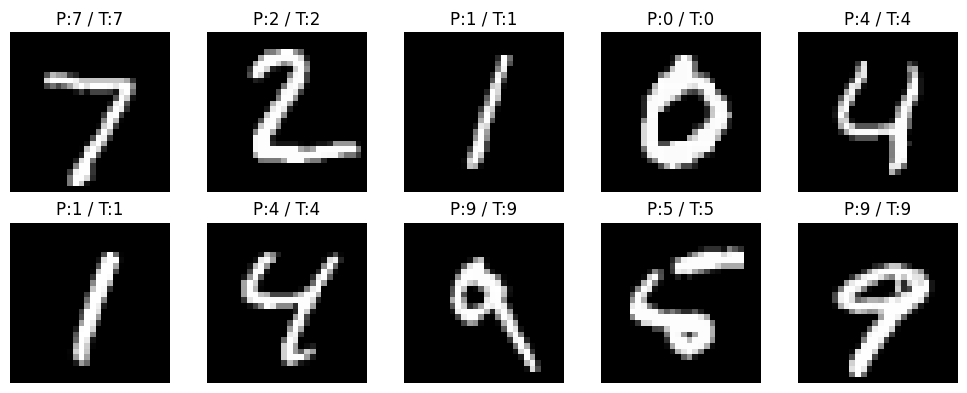

In [7]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].squeeze(0)
    plt.imshow(img, cmap="gray")
    plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Deep CNN (Dropout 포함) - Keras 심화 버전 대응

- 기존 Keras의 더 깊은 구조(다중 Conv + Dropout + Dense)를 PyTorch로 옮긴 예제입니다.

In [8]:
class DeepMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


deep_model = DeepMNISTCNN().to(device)
deep_criterion = nn.CrossEntropyLoss()
deep_optimizer = optim.Adam(deep_model.parameters(), lr=1e-3)

print(deep_model)

DeepMNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.5, inplace=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=256, out_features=10, bia

In [ ]:
deep_epochs = 5
for epoch in range(1, deep_epochs + 1):
    train_loss, train_acc = train_one_epoch(deep_model, train_loader, deep_criterion, deep_optimizer, device)
    test_loss, test_acc = evaluate(deep_model, test_loader, deep_criterion, device)
    print(f"[Deep] Epoch {epoch}/{deep_epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
 
 # RTX 3060 소요 시간: 약 1.43분   
 # Colab A100 소요 시간: 약 1분

[Deep] Epoch 1/5 | Train Loss: 0.2567, Train Acc: 0.9183 | Test Loss: 0.0560, Test Acc: 0.9826
[Deep] Epoch 2/5 | Train Loss: 0.0875, Train Acc: 0.9763 | Test Loss: 0.0380, Test Acc: 0.9886
[Deep] Epoch 3/5 | Train Loss: 0.0716, Train Acc: 0.9801 | Test Loss: 0.0273, Test Acc: 0.9921
[Deep] Epoch 4/5 | Train Loss: 0.0625, Train Acc: 0.9828 | Test Loss: 0.0220, Test Acc: 0.9926
[Deep] Epoch 5/5 | Train Loss: 0.0536, Train Acc: 0.9851 | Test Loss: 0.0223, Test Acc: 0.9926


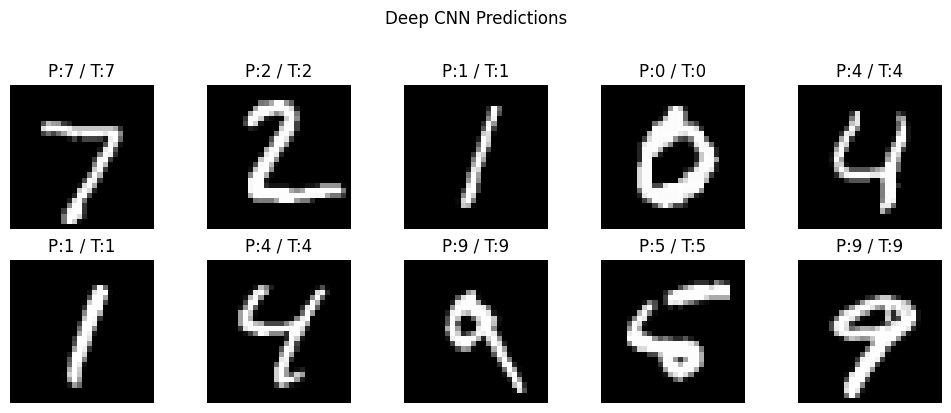

In [10]:
deep_model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = deep_model(images)
    preds = outputs.argmax(dim=1)

# Tensor를 CPU 메모리로 다시 복사 , GPU로 이동 할때는: images.cuda()
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].squeeze(0)
    plt.imshow(img, cmap="gray")
    plt.title(f"P:{preds[i].item()} / T:{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Deep CNN Predictions", y=1.02)
plt.tight_layout()
plt.show()